# Cross-checks with other codes

The regression suite is thorough about algebra and, unavoidably, self-consistent about **conventions**. `scipy.linalg.expm` confirms that $U$ is the matrix exponential of the Hamiltonian — but of the Hamiltonian this library built. The standard oscillation formulas were transcribed from the same papers the builders were. A mixing-matrix ordering, a sign or a unit conversion that was wrong *consistently* across the package would sit comfortably inside all of it.

Corroboration from outside is what closes that gap. This notebook collects two sources of it — an independently written code, and a published closed form reached by a different route. Both agree; the interesting part is what had to be lined up first.

---

### The answer, up front

Once two conventions are matched — a length unit and an electron density, both differences in *definition* rather than errors in either code — this library and [nuSQuIDS](https://github.com/arguelles/nuSQuIDS) agree to between $4\times10^{-16}$ and $3\times10^{-10}$ across eleven configurations, and the Zaglauer–Schwarzer closed form reproduces the matter spectrum to $7\times10^{-16}$ at any configuration asked of it.

| Checked | By |
|---|---|
| $U$ is $e^{-iHL}$ | `scipy.linalg.expm`, in the suite |
| The Hamiltonian we build is the right one | nuSQuIDS, and Zaglauer–Schwarzer for the matter spectrum |
| Mixing conventions, $\theta_{23}$, $\delta_{CP}$ | nuSQuIDS, and the vacuum reference formulas |
| The antineutrino rule — conjugate *and* flip | nuSQuIDS, three and four flavors, vacuum and matter |
| The mass ordering sign | nuSQuIDS, inverted-ordering case |
| Four-flavor probabilities | nuSQuIDS, at 3e-10 to 4e-16 |
| Arbitrary matter configurations | Zaglauer–Schwarzer, live |

**Not** covered, and worth knowing before leaning on any of it: the frozen set is eleven configurations rather than a parameter space, with $\delta_{CP}$, $\theta_{23}$ and the sterile angles each held at one value; the Zaglauer–Schwarzer check reaches eigenvalues but not mixing; and no external code here exercises `slabs` or `earth`.

The rest of the notebook is how those numbers were arrived at. The closing section returns to this table with the caveats spelled out in full.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

## Two sources of corroboration

**[nuSQuIDS](https://github.com/arguelles/nuSQuIDS)** evolves the neutrino density matrix numerically, in C++. It shares no lineage with the closed-form SU($n$) expansions here, and it is configured from mixing *angles* and a density in g/cm³ rather than from a Hamiltonian — so agreement exercises `hamiltonians3nu` and `hamiltonians4nu` as much as the expansions. It is a considerably more general tool than this one, which is what makes the agreement worth having.

The two arrive at a probability by genuinely different routes, which is the point — a shared mistake is only possible where the routes share something, and these share almost nothing:

| | NuOscProbExact | nuSQuIDS |
|---|---|---|
| You hand it | a Hermitian matrix $H$ and a baseline | mixing angles, $\Delta m^2$, a body and a track |
| Eigenvalues of $H$ | in closed form, from radicals | never formed explicitly |
| Evolution | $U = e^{-iHL}$ built by interpolating the exponential over those eigenvalues | the density matrix integrated numerically along the track |
| You get back | $\lvert U_{\beta\alpha}\rvert^2$ | the evolved flavor state, projected |
| Error comes from | floating-point round-off | the ODE tolerance, plus round-off |

So the comparison below is not one implementation of a formula against another. It is a closed form against a numerical integration, starting from different inputs.

Its values are **frozen** into `tests/nusquids_reference.json` rather than computed here. nuSQuIDS ships manylinux wheels and would install in CI, but a comparison that runs in CI ties this suite to an external project's release cadence. `tests/nusquids_reference.py` regenerates it deliberately.

**Zaglauer–Schwarzer** (Z. Phys. C 40, 273 (1988)) give the exact eigenvalues of the matter Hamiltonian as roots of an explicit cubic in the vacuum parameters — never forming the matrix. That runs live, below, at any configuration and with no dependency.

In [2]:
import json

with open(os.path.join("..", "tests",
                       "nusquids_reference.json")) as handle:
    REF = json.load(handle)

print("nuSQuIDS version :", REF["nusquids_version"])
print("cases            :", len(REF["cases"]))
for case in REF["cases"]:
    print("   ", case["name"])

nuSQuIDS version : 1.13.3
cases            : 11
    3nu vacuum, 1 GeV, 1300 km
    3nu vacuum, 0.6 GeV, 295 km
    3nu matter rho=3, 1 GeV, 1300 km
    3nu matter rho=3, 5 GeV, 1300 km
    4nu vacuum, 1 GeV, 1300 km
    4nu vacuum, 0.5 GeV, 0.6 km
    4nu matter rho=3, 1 GeV, 1300 km
    3nu antinu vacuum, 1 GeV, 1300 km
    3nu antinu matter rho=3, 1 GeV, 1300 km
    3nu matter rho=3, 1 GeV, 1300 km, inverted
    4nu antinu matter rho=3, 1 GeV, 1300 km


## The convention dictionary

Comparing two codes is mostly the work of matching what they mean, not what they compute. There are exactly two differences here, and **both are definitional** — neither is an error in either code.

In [3]:
C = REF["constants"]

# 1. The length unit
print("CONV_KM_TO_INV_EV")
print("  ours      : %.10e" % gd.CONV_KM_TO_INV_EV)
print("  nuSQuIDS  : %.10e   (= 1 km / hbar c)" % C["km"])
print("  relative  : %.2e"
      % abs(gd.CONV_KM_TO_INV_EV/C["km"] - 1.0))

# 2. The electron density behind V_CC
rho, ye = gd.DENSITY_MATTER_CRUST_G_PER_CM3, REF["electron_fraction"]
ne_theirs = rho*C["avogadro"]*ye/C["cm"]**3
vcc_theirs = np.sqrt(2.0)*C["GF"]*ne_theirs
print("\nV_CC at rho = %.1f g/cm^3" % rho)
print("  ours      : %.6e   (1 g / mean nucleon mass)"
      % gd.VCC_EARTH_CRUST)
print("  nuSQuIDS  : %.6e   (rho N_A Y_e)" % vcc_theirs)
print("  ratio     : %.5f  -> %.2f%%, the nuclear mass defect"
      % (vcc_theirs/gd.VCC_EARTH_CRUST,
         100*(vcc_theirs/gd.VCC_EARTH_CRUST - 1.0)))

CONV_KM_TO_INV_EV
  ours      : 5.0677300000e+09
  nuSQuIDS  : 5.0677307162e+09   (= 1 km / hbar c)
  relative  : 1.41e-07

V_CC at rho = 3.0 g/cm^3
  ours      : 1.135602e-13   (1 g / mean nucleon mass)
  nuSQuIDS  : 1.144870e-13   (rho N_A Y_e)
  ratio     : 1.00816  -> 0.82%, the nuclear mass defect


The length unit looks harmless at $1.4\times10^{-7}$, but it multiplies the **accumulated phase**. At 1300 km and 1 GeV that phase is some $2.5\times10^3$ radian; with an eV-scale sterile it is $10^4$. So a seventh-decimal-place constant becomes a fourth-decimal-place probability.

**One asymmetry to be honest about.** Both adjustments are made on *our* side, to match nuSQuIDS — so a sceptic could say the agreement below was fitted rather than found. Two things answer that. The length unit is not a free choice: $1\,$km$/\hbar c$ from CODATA is $5.0677307162\times10^9$, so nuSQuIDS is right and our constant is simply rounded, which is checkable without reference to either code. And two constants cannot fit the result: what follows is eleven cases carrying between nine and sixteen probabilities each, agreeing to round-off. Two knobs do not buy that.

## The comparison

For each frozen case, `ours()` below rebuilds the *same physical situation* from this library: it constructs the vacuum Hamiltonian from the mixing parameters nuSQuIDS was given, adds the matter potential, and evaluates the SU(3) or SU(4) expansion. nuSQuIDS' answer for that situation is already in the JSON.

The two are then compared entry by entry, as $\max_{\alpha\beta}|P^{\rm ours}_{\alpha\beta} - P^{\rm nuSQuIDS}_{\alpha\beta}|$ over the full 3×3 or 4×4 table — a worst case, not an average.

Each case is computed **twice**: once with this library's own constants, and once with nuSQuIDS' — so the effect of matching conventions is shown rather than asserted. Only the constants change between the two columns; the physics and the code path are identical.

In [4]:
def ours(case, km, vcc, vnc):
    """This library's probabilities for one frozen case.

    Antineutrinos need *both* changes: conjugate the vacuum
    Hamiltonian and reverse the sign of the potentials.
    """
    p = REF["parameters"]
    s = np.sin
    E = case["energy_gev"]*GEV
    L = case["baseline_km"]*km
    rho = case["density_g_cm3"]
    anti = case.get("antineutrino", False)
    dm31 = case.get("dm31", p["dm31"])
    sign = -1.0 if anti else 1.0
    if case["n_flavors"] == 3:
        H0 = np.asarray(hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
            s(p["th12"]), s(p["th23"]), s(p["th13"]),
            p["dcp"], p["dm21"], dm31))
        if anti:
            H0 = np.conj(H0)
        H = (H0/E if rho is None else
             hamiltonians3nu.hamiltonian_3nu_matter(
                 H0, E, sign*vcc))
        return np.array(oscprob3nu.probabilities_3nu(
            H, L)).reshape(3, 3)
    H0 = hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(
        s(p["th12"]), s(p["th23"]), s(p["th13"]),
        s(p["th14"]), s(p["th24"]), s(p["th34"]),
        p["dcp"], p["dm21"], dm31, p["dm41"])
    if anti:
        H0 = np.conj(H0)
    H = (H0/E if rho is None else
         hamiltonians4nu.hamiltonian_4nu_matter(
             H0, E, sign*vcc, sign*vnc))
    return np.array(oscprob4nu.probabilities_4nu(
        H, L)).reshape(4, 4)


def potentials(rho, matched):
    """(V_CC, V_NC) in either convention."""
    if rho is None:
        return None, None
    if not matched:
        scale = rho/gd.DENSITY_MATTER_CRUST_G_PER_CM3
        return (gd.VCC_EARTH_CRUST*scale,
                gd.VNC_EARTH_CRUST*scale)
    ye = REF["electron_fraction"]
    ne = rho*C["avogadro"]*ye/C["cm"]**3
    nn = rho*C["avogadro"]*(1.0 - ye)/C["cm"]**3
    return (np.sqrt(2.0)*C["GF"]*ne,
            -C["GF"]*nn/np.sqrt(2.0))


names, unmatched, matched_ = [], [], []
for case in REF["cases"]:
    theirs = np.array(case["probabilities"])
    rho = case["density_g_cm3"]
    a = np.max(np.abs(ours(case, gd.CONV_KM_TO_INV_EV,
                           *potentials(rho, False)) - theirs))
    b = np.max(np.abs(ours(case, C["km"],
                           *potentials(rho, True)) - theirs))
    names.append(case["name"])
    unmatched.append(a)
    matched_.append(b)

print("%-36s %11s %11s" % ("case", "our conv.", "matched"))
for n, a, b in zip(names, unmatched, matched_):
    print("%-36s %11.2e %11.2e" % (n, a, b))

case                                   our conv.     matched
3nu vacuum, 1 GeV, 1300 km              5.41e-07    2.22e-15
3nu vacuum, 0.6 GeV, 295 km             1.49e-08    1.38e-14
3nu matter rho=3, 1 GeV, 1300 km        2.40e-04    6.59e-12
3nu matter rho=3, 5 GeV, 1300 km        4.65e-05    1.55e-12
4nu vacuum, 1 GeV, 1300 km              9.80e-05    4.65e-11
4nu vacuum, 0.5 GeV, 0.6 km             1.36e-08    3.89e-16
4nu matter rho=3, 1 GeV, 1300 km        5.01e-04    2.35e-11
3nu antinu vacuum, 1 GeV, 1300 km       5.41e-07    2.11e-15
3nu antinu matter rho=3, 1 GeV, 1300 km    1.29e-05    9.06e-13
3nu matter rho=3, 1 GeV, 1300 km, inverted    2.62e-05    9.68e-13
4nu antinu matter rho=3, 1 GeV, 1300 km    5.82e-04    2.98e-10


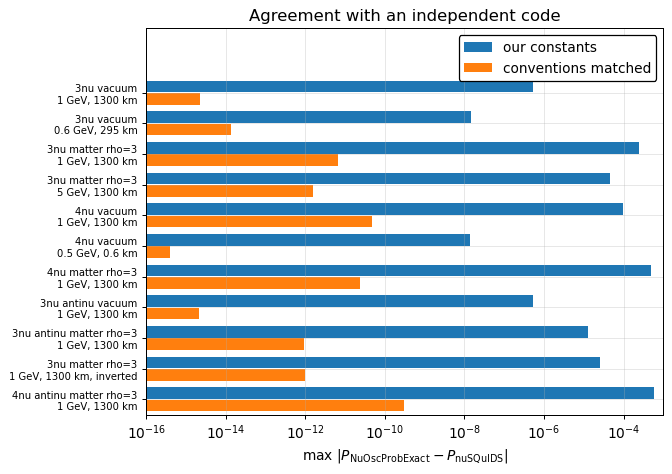

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 5.4))
y = np.arange(len(names))
ax.barh(y - 0.2, unmatched, height=0.38,
        label="our constants")
ax.barh(y + 0.2, matched_, height=0.38,
        label="conventions matched")
ax.set_yticks(y)
ax.set_yticklabels([n.replace(", ", "\n", 1) for n in names],
                   fontsize=8)
ax.set_xscale("log")
ax.set_xlim(1e-16, 1e-3)
ax.set_xlabel(r"max $|P_{\rm NuOscProbExact} - P_{\rm nuSQuIDS}|$")
ax.set_title("Agreement with an independent code")
ax.invert_yaxis()
# Headroom above the first bar so the legend sits clear
# of it rather than on top of it.
ax.set_ylim(len(names) - 0.5, -2.1)
ax.legend(loc="upper right", frameon=True,
          edgecolor="black", framealpha=1.0)
ax.grid(True, axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

Matched, the two codes agree between $10^{-10}$ and $10^{-15}$ — round-off, for two implementations that share nothing. Everything to the left of that in the "our constants" bars is convention, not physics.

The **four-flavor rows** deserve their own note. `oscprob4nu` is new, and until this comparison it was validated only against `scipy.linalg.expm` and against its own three-flavor limit. It is now checked by an outside code, across a range that tracks how stiff the spectrum is: $3.9\times10^{-16}$ at a short baseline where it is benign, $2.4\times10^{-11}$ in matter, and $3.0\times10^{-10}$ for antineutrinos in matter, which is the stiffest case here. That last one is the accuracy `POLISH_ROOTS` documents, arrived at independently; it is attributed at the end of this notebook rather than left hanging.

## A second check: matter eigenvalues, live

The nuSQuIDS comparison above is frozen at eleven configurations. This one runs at **any** configuration, with no external dependency — but it checks something narrower, and it is worth being exact about what.

### What is compared with what

Both sides produce the **three eigenvalues of the same object**: the effective mass-squared matrix in matter,

$$M^2_{\rm eff} = U M^2 U^\dagger + \mathrm{diag}(A, 0, 0), \qquad A = 2EV_{CC},$$

in units of eV$^2$. They reach them from opposite directions:

| | Our side | Zaglauer–Schwarzer |
|---|---|---|
| Starts from | the $3\times3$ matrix `hamiltonians3nu` builds | the numbers $\theta_{12}, \theta_{13}, \Delta m^2_{21}, \Delta m^2_{31}, A$ |
| Is a matrix ever formed? | yes — that is the thing being tested | **no** |
| Route to the eigenvalues | `numpy.linalg.eigvalsh`, i.e. LAPACK | an explicit cubic, solved in radicals |

The Hamiltonian this library builds is $H = M^2_{\rm eff}/(2E)$, so multiplying it by $2E$ recovers $M^2_{\rm eff}$ and the two sides become directly comparable. That factor is the only manipulation applied.

### What this does and does not exercise

It tests **`hamiltonians3nu`, not `oscprob3nu`**. The SU(3) expansion never runs here: the left-hand side goes through LAPACK, not through the closed form. What is under test is whether the *matrix we assembled* is the right one — the PMNS parametrization, the placement of $V_{CC}$ on the $ee$ entry, and the relative normalization of the vacuum and matter terms. Those are conventions, and conventions are exactly what an internal test cannot catch.

It also stops at eigenvalues. Eigenvalues fix the oscillation *frequencies* but not the amplitudes, so this says nothing about the mixing — that is what nuSQuIDS and the vacuum reference formulas cover.

One detail that keeps it honest: the $|U_{ei}|^2$ in the formula below are written from the mixing angles directly, as $c_{12}^2c_{13}^2$, $s_{12}^2c_{13}^2$ and $s_{13}^2$, rather than read out of `pmns_mixing_matrix`. Had they been taken from our own mixing matrix, an error in it would appear on both sides and cancel.

In [6]:
def zaglauer_schwarzer(s12, s13, dm21, dm31, A):
    """Exact eigenvalues of M^2_eff, from the vacuum parameters."""
    c13sq = 1.0 - s13*s13
    ue1, ue2, ue3 = (1.0 - s12*s12)*c13sq, s12*s12*c13sq, s13*s13
    # lambda^3 - x lambda^2 + y lambda - z = 0, whose three
    # roots are the eigenvalues of M^2_eff
    x = dm21 + dm31 + A
    y = dm21*dm31 + A*(dm21*(1.0 - ue2) + dm31*(1.0 - ue3))
    z = A*dm21*dm31*ue1
    p = y - x*x/3.0
    q = -2.0*x**3/27.0 + x*y/3.0 - z
    t = 2.0*np.sqrt(-p/3.0)
    th = np.arccos(np.clip(3.0*q/(p*t), -1.0, 1.0))
    return np.sort(t*np.cos((th + 2.0*np.pi*np.arange(3))/3.0)
                   + x/3.0)


VCC = gd.VCC_EARTH_CRUST
E_gev = np.logspace(-0.5, 2.0, 400)

tracks, deviations = [], []
for e in E_gev:
    E = e*GEV

    # OUR SIDE: build the matter Hamiltonian, then
    # diagonalise it numerically.  H = M^2_eff/(2E), so
    # multiplying by 2E gives back M^2_eff in eV^2.
    # Note this goes through LAPACK, not through the
    # SU(3) expansion -- what is under test here is the
    # matrix, not the solver.
    H = np.asarray(hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, E, VCC))
    mine = np.sort(np.linalg.eigvalsh(2.0*E*H))

    # THEIR SIDE: the same three eigenvalues, straight
    # from the vacuum parameters and A = 2 E V_CC.  No
    # matrix is built at any point.
    theirs = zaglauer_schwarzer(gd.S12_NO_BF, gd.S13_NO_BF,
                                gd.D21_NO_BF, gd.D31_NO_BF,
                                2.0*E*VCC)

    # Compare, scaled by the size of the spectrum
    tracks.append(mine)
    deviations.append(np.max(np.abs(mine - theirs))
                      / np.max(np.abs(mine)))
tracks = np.array(tracks)
deviations = np.array(deviations)

print("worst relative deviation over the scan: %.2e"
      % deviations.max())

worst relative deviation over the scan: 1.34e-15


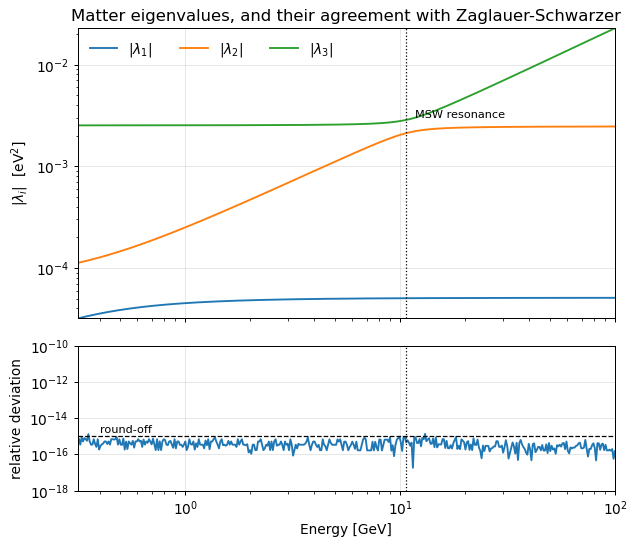

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(7.2, 6.2),
                         sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

for i in range(3):
    axes[0].loglog(E_gev, np.abs(tracks[:, i]),
                   label=r"$|\lambda_%d|$" % (i + 1))
c2th13 = 1.0 - 2.0*gd.S13_NO_BF**2
E_res = gd.D31_NO_BF*c2th13/(2.0*VCC)/GEV
axes[0].axvline(E_res, color="k", ls=":", lw=1)
axes[0].text(E_res*1.1, 3e-3, "MSW resonance", fontsize=9)
axes[0].set_ylabel(r"$|\lambda_i|$  [eV$^2$]")
axes[0].set_title("Matter eigenvalues, and their agreement "
                  "with Zaglauer-Schwarzer")
axes[0].legend(ncol=3)

axes[1].loglog(E_gev, np.maximum(deviations, 1e-18), "-")
axes[1].axhline(1e-15, color="k", ls="--", lw=1)
axes[1].text(0.4, 1.6e-15, "round-off", fontsize=9)
axes[1].axvline(E_res, color="k", ls=":", lw=1)
axes[1].set_ylim(1e-18, 1e-10)
axes[1].set_xlim(E_gev[0], E_gev[-1])
axes[1].set_xlabel("Energy [GeV]")
axes[1].set_ylabel("relative deviation")
fig.tight_layout()
plt.show()

The upper panel is the physics: the three eigenvalues of $M^2_{\rm eff}$ as the energy rises, computed from our matrix. Two of them approach near 10 GeV — the MSW resonance, marked — and then swap character, which is the level crossing that drives matter effects.

The lower panel is the check: at each energy, the largest difference between those eigenvalues and the Zaglauer–Schwarzer ones, relative to the spectral scale. It sits at round-off across two and a half decades of energy, including through the resonance — which is where the two eigenvalues come closest and any error in how the matrix was assembled would show first.

The dotted line marks $A = \Delta m^2_{31}\cos2\theta_{13}$, the two-flavor resonance condition; the true minimum-gap energy is about 1% lower, the difference being the solar term that condition omits.

One transcription note, because it is the kind of mistake that usually produces a plausible wrong curve rather than an obvious one: the depressed cubic's constant term is $-2x^3/27 + xy/3 - z$. Written first with the signs of the first two terms flipped, it disagreed with the spectrum by 50% — large enough to be unmissable, which was luck. The corrected form is identical to the resolvent cubic already inside `oscprob4nu`, which is where it should have been checked against from the start.

## What each code is for

Agreement is one question; which tool suits a given calculation is another. The two are built for different things that happen to overlap.

| If you need | Reach for |
|---|---|
| Constant or piecewise-constant density | either — this library gives it in closed form |
| The evolution operator returned directly | this library |
| Two, three or four flavors | either |
| More than four flavors | nuSQuIDS |
| A profile varying continuously along the trajectory | nuSQuIDS, or Magnus |
| Neutrino–nucleon interactions, attenuation | nuSQuIDS |
| Tau regeneration | nuSQuIDS |
| Open-system, non-unitary evolution | nuSQuIDS |

On the overlap the closed form is quicker, because it evaluates an expression where nuSQuIDS integrates a density matrix. That is a difference in what each is solving rather than a measure of either — the integration is what buys the rest of the column above, and a calculation that needs any of it is not one a closed form can serve.

The same reasoning marks this library's own boundary. Where a profile varies appreciably over an oscillation length — the Sun, adiabatic MSW — slabbing stops being practical and a Magnus-type method is the right tool. Notebook 14 shows where that begins.

## What this covers, and what it does not

Worth being precise, since "validated against an independent code" is easy to over-claim.

| Checked | By |
|---|---|
| $U$ is $e^{-iHL}$ | `scipy.linalg.expm`, in the suite |
| The Hamiltonian we build is the right one | nuSQuIDS, and Zaglauer–Schwarzer for the matter spectrum |
| Mixing-matrix conventions, $\theta_{23}$, $\delta_{CP}$ | nuSQuIDS, and the vacuum reference formulas |
| **The antineutrino rule** — conjugate *and* flip | nuSQuIDS, three and four flavors, vacuum and matter |
| **The mass ordering sign** | nuSQuIDS, inverted-ordering case |
| Four-flavor probabilities | nuSQuIDS, at 3e-10 to 4e-16 |
| Arbitrary matter configurations | Zaglauer–Schwarzer, live |

The antineutrino and mass-ordering rows are there deliberately. Those are the two sign conventions this library has a history of getting wrong — the 1.1.0 release fixed a two-flavor vacuum Hamiltonian built with the opposite sign, invisible in vacuum and wrong the moment matter was added — so a comparison meant to catch convention errors ought to exercise them. The three-flavor cases agree at $10^{-13}$ to $10^{-15}$; the four-flavor antineutrino case is the stiffest configuration here and is discussed just below.

What is still **not** covered: Zaglauer–Schwarzer eigenvalues are independent of $\theta_{23}$ and $\delta_{CP}$, since only the electron row of $U$ enters the matter term — and eigenvalues are not probabilities. The frozen nuSQuIDS set is eleven configurations, not a parameter space: $\delta_{CP}$, $\theta_{23}$ and the sterile angles are each held at one value. And no external code here exercises `slabs` or `earth`, whose layered composition is checked internally against `expm` instead.

One residual is worth naming rather than hiding. The four-flavor *antineutrino* case agrees least well, at $3\times10^{-10}$. That is not a convention gap: against `scipy.linalg.expm` on the same Hamiltonian, our error is $3.0\times10^{-10}$ and nuSQuIDS' is $3.4\times10^{-12}$ — so the whole residual is ours, and it is the stiff-spectrum limit that `POLISH_ROOTS` documents, reached independently. A test in the suite pins that attribution, so a convention error could not later hide behind the same loose tolerance.

---

**Previous:** [Four neutrinos, and a sterile state](16_four_neutrinos.ipynb)  
**Next:** [The evolution operator and the SU(n) coefficients](18_evolution_operator.ipynb) --- the machinery underneath, for composing and extending  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)